In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

df.to_csv("titanic.csv", index=False)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (891, 15)


In [45]:
print("Dataset Information:")
df.info()

print("\nDataset Shape:")
print(df.shape)

print("\nDescriptive Statistics:")
display(df.describe())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Dataset Shape:
(891, 15)

Descriptive Statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [46]:
missing_percent = (df.isnull().mean() * 100).round(2)

missing_percent = missing_percent[missing_percent > 0]

print("Missing Values (%):")
print(missing_percent)

Missing Values (%):
age            19.87
embarked        0.22
deck           77.22
embark_town     0.22
dtype: float64


### Initial Data Profile

The Titanic dataset was loaded once using Seaborn and saved as `titanic.csv` for offline use.

I reviewed the dataset shape, data types, summary statistics, and missing-value percentages before applying any cleaning. The missing-value percentages will be used to decide the cleaning strategy for each affected column.

### Missing Value Analysis

I calculated the percentage of missing values before cleaning the dataset.

Based on the required cleaning rules:

- `age` has between 5% and 30% missing values, so I will fill the missing values using the median age.
- `embarked` has less than 5% missing values, so rows where this value is missing will be removed.
- `embark_town` also has less than 5% missing values, so rows with missing values will be removed.
- `deck` has a very high percentage of missing values. I decided to remove this column because most passenger records do not contain a deck value, making reliable imputation difficult.

In [47]:

df_clean = df.copy()


median_age = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(median_age)


df_clean = df_clean.dropna(subset=["embarked", "embark_town"])


df_clean = df_clean.drop(columns=["deck"])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nOriginal shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Original shape: (891, 15)
Cleaned shape: (889, 14)


In [48]:
remaining_missing = df_clean.isnull().sum().sum()

print("Total missing values remaining:", remaining_missing)

Total missing values remaining: 0


In [49]:
df_clean.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [50]:
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 116


In [51]:
rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

rows_after = len(df_clean)

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

Rows before removing duplicates: 889
Rows after removing duplicates: 773
Duplicates removed: 116


### Duplicate Check

###I checked the cleaned dataset for completely duplicated rows using pandas `duplicated()`.

##Any duplicate rows found were removed using `drop_duplicates()` to avoid repeated passenger records influencing the analysis. If no duplicates were found, the dataset was left unchanged.###

In [52]:
df_clean.to_csv("titanic_cleaned.csv", index=False)

print("Updated cleaned dataset saved.")

Updated cleaned dataset saved.


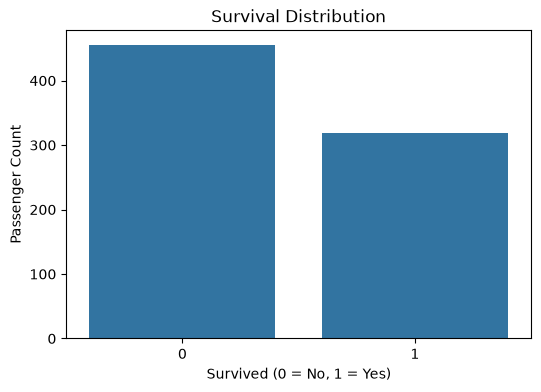

survived
0    455
1    318
Name: count, dtype: int64

Percentage:
survived
0    58.86
1    41.14
Name: proportion, dtype: float64


In [53]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="survived"
)

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passenger Count")
plt.show()

print(df_clean["survived"].value_counts())
print("\nPercentage:")
print(df_clean["survived"].value_counts(normalize=True).mul(100).round(2))

### Survival Distribution Interpretation

The survival distribution shows that more passengers did not survive than survived. This indicates that the target variable is not evenly distributed between the two classes.

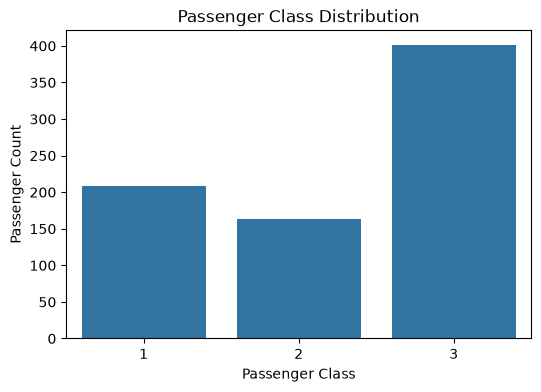

pclass
1    208
2    164
3    401
Name: count, dtype: int64


In [54]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="pclass"
)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.show()

print(df_clean["pclass"].value_counts().sort_index())

### Passenger Class Interpretation

The dataset contains passengers from all three ticket classes. Third class contains the largest number of passenger records, while first and second class contain fewer passengers.

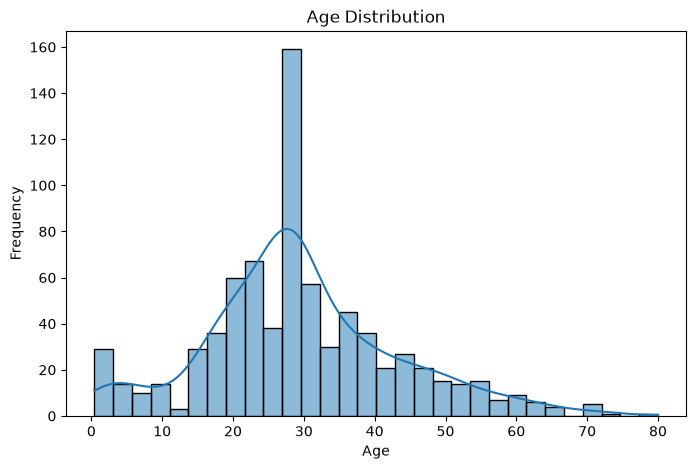

count    773.000000
mean      29.528357
std       13.731264
min        0.420000
25%       21.000000
50%       28.000000
75%       36.000000
max       80.000000
Name: age, dtype: float64


In [55]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print(df_clean["age"].describe())

### Age Distribution Interpretation

The age distribution is concentrated mainly among younger and middle-aged passengers. There are fewer passengers at the higher end of the age range. Missing age values were already handled using median imputation before this analysis.

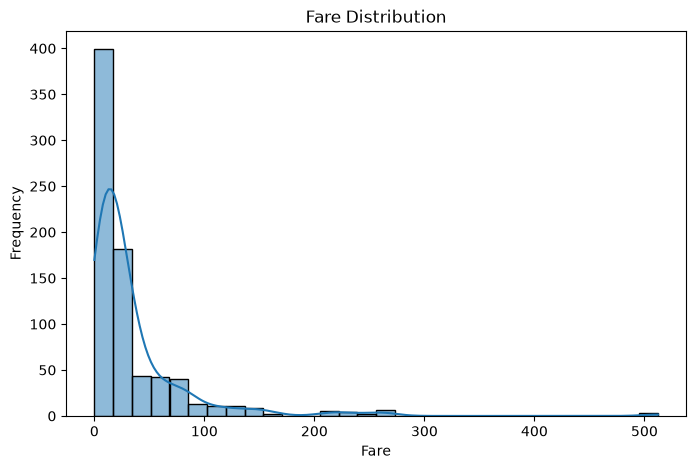

count    773.000000
mean      34.761659
std       52.425906
min        0.000000
25%        8.050000
50%       15.900000
75%       33.500000
max      512.329200
Name: fare, dtype: float64


In [56]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="fare",
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

print(df_clean["fare"].describe())

### Fare Distribution Interpretation

The fare distribution is right-skewed. Most passengers paid relatively lower fares, while a smaller number of passengers paid substantially higher fares.

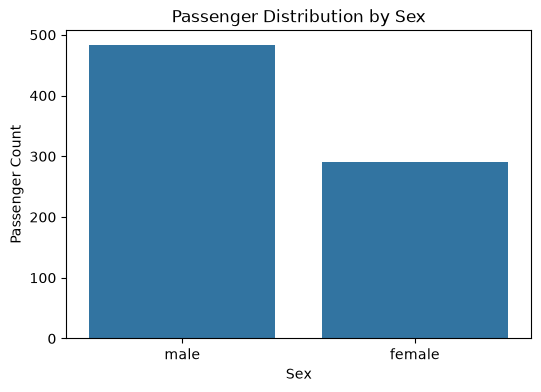

sex
male      483
female    290
Name: count, dtype: int64


In [57]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="sex"
)

plt.title("Passenger Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")
plt.show()

print(df_clean["sex"].value_counts())

### Sex Distribution Interpretation

The dataset contains more male passengers than female passengers. This difference is useful to keep in mind when later comparing survival outcomes across groups.

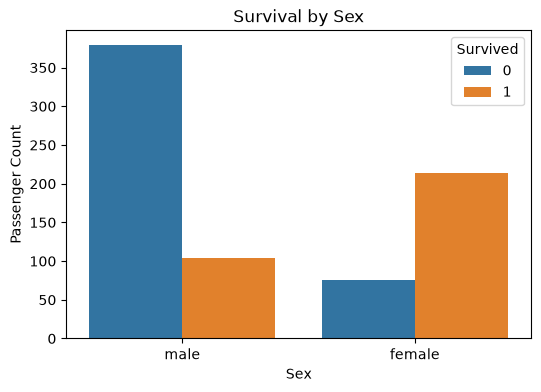

Survival rate by sex (%):
sex
female    73.79
male      21.53
Name: survived, dtype: float64


In [58]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="sex",
    hue="survived"
)

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")
plt.legend(title="Survived")
plt.show()

survival_by_sex = (
    df_clean.groupby("sex", observed=False)["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by sex (%):")
print(survival_by_sex)

### Survival by Sex Interpretation

The survival rate differs noticeably between male and female passengers. Female passengers have a higher survival rate than male passengers, suggesting that sex is an important feature for predicting survival.

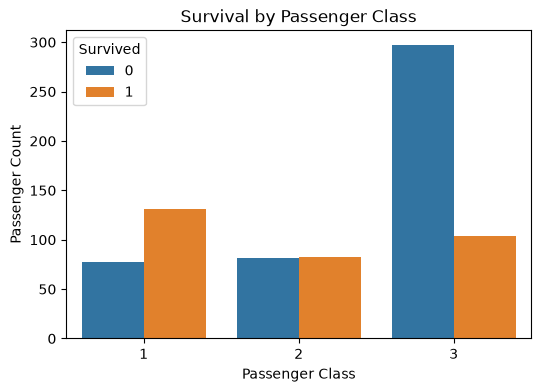

Survival rate by passenger class (%):
pclass
1    62.98
2    50.61
3    25.94
Name: survived, dtype: float64


In [59]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="pclass",
    hue="survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.legend(title="Survived")
plt.show()

survival_by_class = (
    df_clean.groupby("pclass")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by passenger class (%):")
print(survival_by_class)

### Survival by Passenger Class Interpretation

Survival varies across passenger classes. First-class passengers have a higher survival rate, while third-class passengers have a lower survival rate. This suggests that passenger class may be useful for predicting survival.

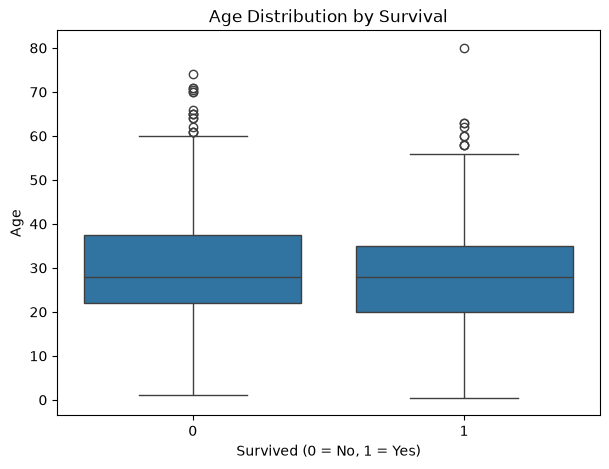

In [60]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

### Age and Survival Interpretation

The age distributions of survivors and non-survivors overlap considerably. Age alone may not clearly separate the two groups, but it may still provide useful information when combined with other passenger characteristics.

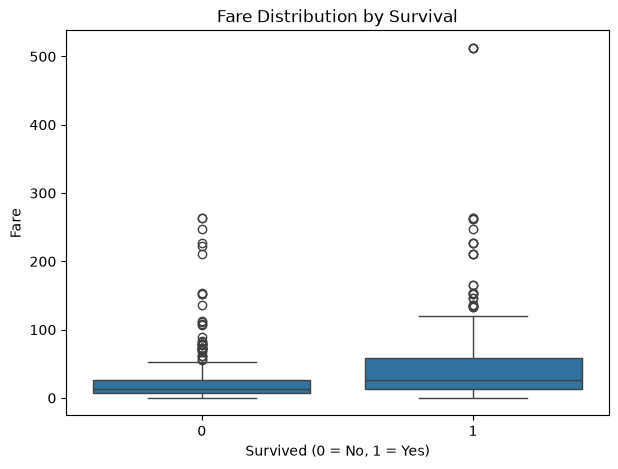

In [61]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()

### Fare and Survival Interpretation

Passengers who survived tend to include more passengers with higher fares. This relationship may also reflect passenger class, since higher fares are often associated with higher travel classes.

In [62]:
numeric_df = df_clean.select_dtypes(include=["number"])

correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.00,-0.33,-0.08,-0.04,0.07,0.25
pclass,-0.33,1.00,-0.34,0.09,0.04,-0.55
age,-0.08,-0.34,1.00,-0.28,-0.18,0.09
sibsp,-0.04,0.09,-0.28,1.00,0.38,0.14
parch,0.07,0.04,-0.18,0.38,1.00,0.19
fare,0.25,-0.55,0.09,0.14,0.19,1.00


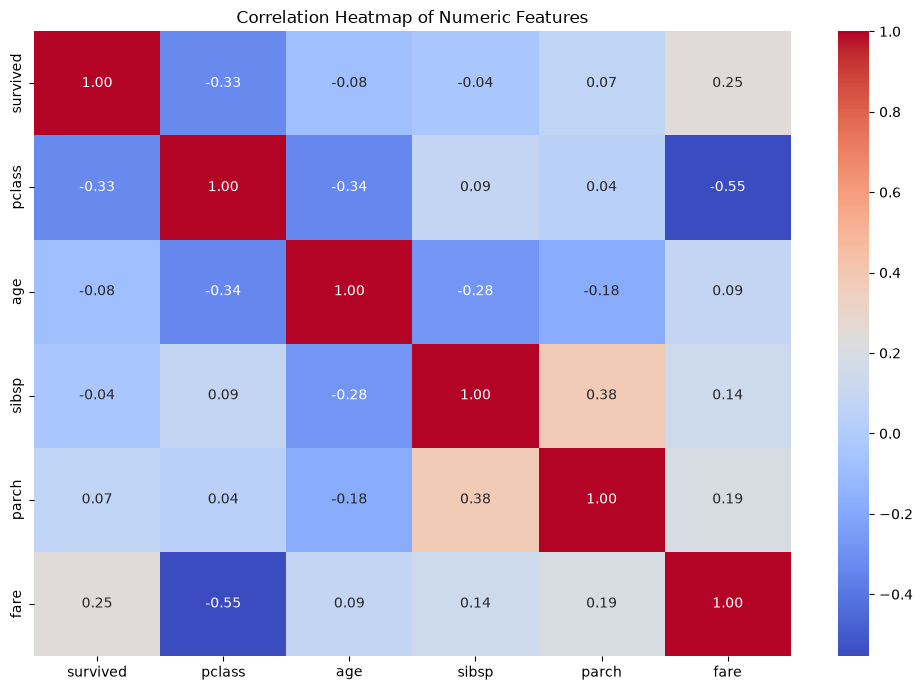

In [63]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

### Correlation Heatmap Interpretation

The correlation heatmap shows the relationships among the numeric features in the cleaned dataset.

Passenger class (`pclass`) has a negative relationship with survival, which is consistent with the earlier observation that passengers in first class had a higher survival rate than passengers in third class.

Fare has a positive relationship with survival. Passengers who paid higher fares were more likely to survive, although fare is also related to passenger class.

The heatmap also shows relationships among family-related variables such as `sibsp` and `parch`. These relationships should be considered when selecting features for the predictive models.

Correlation alone does not prove that one variable causes another, but it helps identify potentially useful relationships for further analysis and modeling.

In [64]:
model_df = df_clean[
    [
        "survived",
        "pclass",
        "sex",
        "age",
        "sibsp",
        "parch",
        "fare",
        "embarked"
    ]
].copy()

print("Modeling dataset:")
display(model_df.head())

print("\nShape:", model_df.shape)

Modeling dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S



Shape: (773, 8)


In [65]:
model_df = pd.get_dummies(
    model_df,
    columns=["sex", "embarked"],
    drop_first=True,
    dtype=int
)

display(model_df.head())

print("\nColumns:")
print(model_df.columns.tolist())

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1



Columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']


In [66]:
X = model_df.drop(columns=["survived"])
y = model_df["survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (773, 8)
y shape: (773,)

Features:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']

Target distribution:
survived
0    455
1    318
Name: count, dtype: int64


### Feature Preparation

The target variable for the predictive analysis is `survived`.

I selected passenger class, sex, age, number of siblings or spouses, number of parents or children, fare, and embarkation point as predictor variables.

Categorical variables cannot be passed directly into the selected machine-learning models, so `sex` and `embarked` were converted into numeric dummy variables using one-hot encoding.

I used `drop_first=True` to avoid keeping redundant dummy columns. The final dataset contains only numeric features and is ready for train/test splitting and model development.

In [67]:
model_df.to_csv(
    "outputs/model_ready_data.csv",
    index=False
)

print("Model-ready dataset saved.")

Model-ready dataset saved.


## Outlier Detection and Treatment## Outlier Detection and Treatment

In [68]:
numeric_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

outlier_summary = []

for column in numeric_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    outlier_summary.append({
        "Column": column,
        "Outliers": len(outliers),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Outliers,Lower Bound,Upper Bound
0,survived,0,-1.50,2.50
1,pclass,0,-2.00,6.00
2,age,26,-1.50,58.50
3,sibsp,39,-1.50,2.50
4,parch,15,-1.50,2.50
5,fare,100,-30.12,71.68


In [69]:
Q1 = df_clean["fare"].quantile(0.25)
Q3 = df_clean["fare"].quantile(0.75)

IQR = Q3 - Q1

fare_lower = Q1 - 1.5 * IQR
fare_upper = Q3 + 1.5 * IQR

print("Fare lower bound:", round(fare_lower, 2))
print("Fare upper bound:", round(fare_upper, 2))

df_clean["fare"] = df_clean["fare"].clip(
    lower=fare_lower,
    upper=fare_upper
)

print("Fare outliers treated using IQR-based capping.")

Fare lower bound: -30.12
Fare upper bound: 71.68
Fare outliers treated using IQR-based capping.


### Outlier Treatment Decision

I used the IQR method to identify potential outliers in the numeric variables.

For `fare`, I retained the passenger records but capped extreme values at the IQR boundaries instead of deleting the rows. High fares can represent legitimate first-class passengers, so removing these observations could discard meaningful information. Capping reduces the influence of extreme values while preserving the records for analysis.

In [70]:
df_clean["age_band"] = pd.cut(
    df_clean["age"],
    bins=[0, 12, 18, 35, 60, float("inf")],
    labels=[
        "Child",
        "Teen",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

print(df_clean["age_band"].value_counts().sort_index())

age_band
Child           68
Teen            67
Young Adult    428
Adult          190
Senior          20
Name: count, dtype: int64


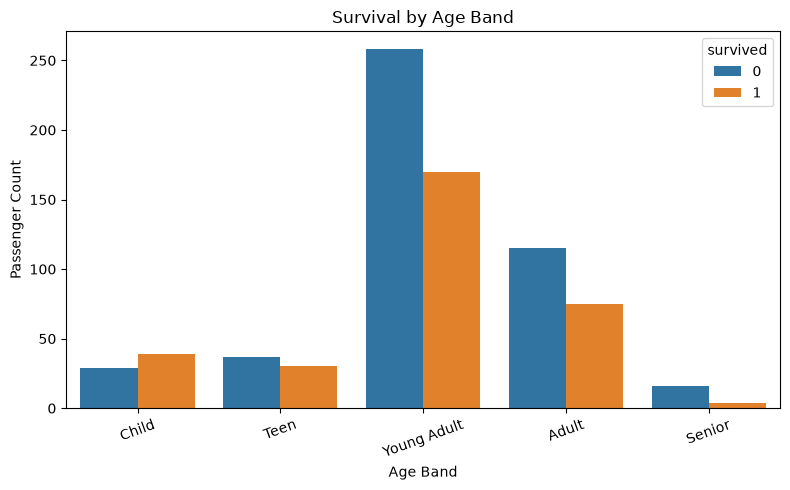

In [71]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="age_band",
    hue="survived"
)

plt.title("Survival by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Passenger Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Engineered Feature: Age Band

I created an `age_band` feature by grouping passenger ages into Child, Teen, Young Adult, Adult, and Senior categories.

This feature makes age-related patterns easier to interpret than using individual ages alone. Comparing age bands with survival also helps reveal whether particular life-stage groups show different survival patterns.

In [72]:
df_clean.to_csv(
    "titanic_cleaned.csv",
    index=False
)

print("Final cleaned dataset saved.")

Final cleaned dataset saved.


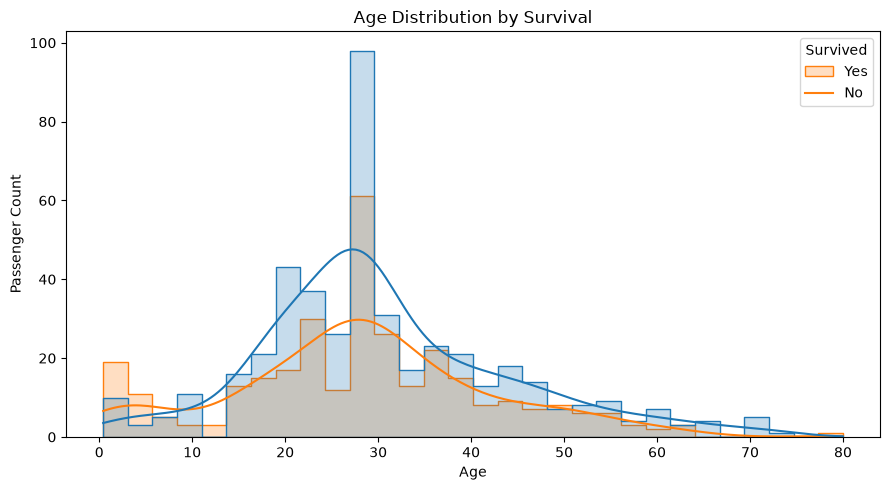

In [73]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="age",
    hue="survived",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.legend(
    title="Survived",
    labels=["Yes", "No"]
)

plt.tight_layout()
plt.show()

### Age Distribution by Survival

The age distributions of survivors and non-survivors overlap considerably, showing that age alone does not clearly separate the two groups. However, differences can be observed across parts of the age distribution, suggesting that age may still contribute useful information when combined with other passenger characteristics.

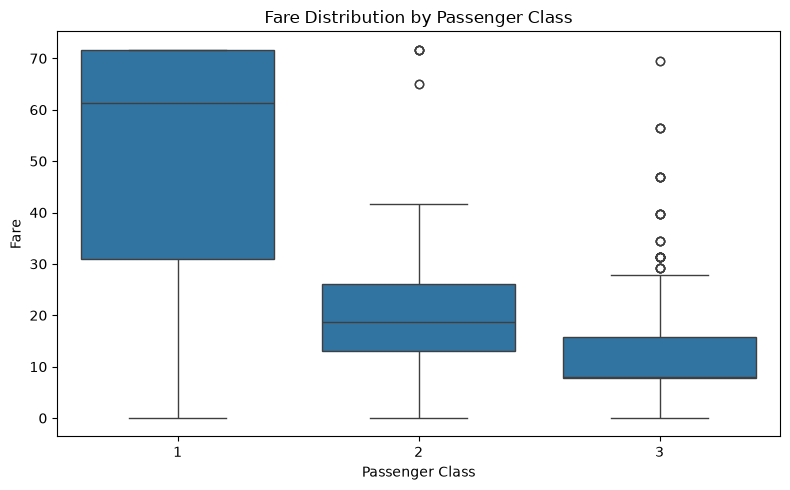

In [74]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="pclass",
    y="fare"
)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

### Fare by Passenger Class

Fare differs substantially across passenger classes. First-class passengers generally paid higher fares, while third-class passengers tended to pay lower fares. This relationship indicates that fare and passenger class contain related information and should be considered together when interpreting the predictive models.